# Demonstration and Evaluation of `srivastava_2005_sphericity`

This notebook demonstrates the usage and evaluates the properties of the covariance sphericity testing method `srivastava_2005_sphericity` from `covtest.methods.hypothesis_spherical`.

## Hypothesis Tested
We test the null hypothesis:
$$H_0: \Sigma = \sigma^2 I_p$$
for some unknown scale parameter $\sigma^2 > 0$, against the alternative hypothesis:
$$H_1: \Sigma \neq \sigma^2 I_p$$
where $\Sigma$ is the population covariance matrix of the data, and $I_p$ is the identity matrix of dimension $p$.

Unlike identity covariance tests, sphericity tests are scale-invariant: multiplying the data or the covariance matrix by a positive constant does not change the test statistic or the p-value.

## Method Description
Srivastava (2005) sphericity test designed for high-dimensional settings (p >> n).

## Notebook Contents
1. **Setup and Imports**
2. **Basic Usage**
3. **P-value Calibration Under the Null**: Checking uniformity of p-values under different distributions (Gaussian, Student-t, Laplace) using a scaled spherical covariance $\Sigma = 3.0 \cdot I_p$.
4. **Power Analysis Under Alternatives**: Power curves across different sample sizes ($n$), dimensions ($p$), and alternative covariance types (spiked, Toeplitz).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Ensure project root is in the path
sys.path.insert(0, os.path.abspath('..'))

from covtest.methods.hypothesis_spherical import srivastava_2005_sphericity
from covtest.simulation.generate_data import generate_heavy_tailed_samples
from covtest.simulation.generate_covariances import (
    generate_toeplitz_cov,
    generate_spiked_covariance
)
from covtest.diagnostics.evaluate_pvalues import analyze_pvalues
from covtest.plotting.null import plot_pvalue_diagnostics_grid
from covtest.plotting.alternative import plot_power_curve, plot_power_heatmap

# Set up plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
rng = np.random.default_rng(42)


## 2. Basic Usage

Let's run a single test on synthetic data generated under a scaled spherical covariance matrix ($\Sigma = 3.0 \cdot I_p$). A scale-invariant test should fail to reject the null hypothesis despite the inflated variance.


In [2]:
n, p = 100, 50
# Scaled spherical covariance matrix under the null
null_cov = 3.0 * np.eye(p)

# Generate multivariate normal data under the null
X = generate_heavy_tailed_samples(null_cov, n, dist_type="normal", rng=rng)

# Run the test
result = srivastava_2005_sphericity(X)
print("Test Results:")
for k, v in result.items():
    print(f"  {k}: {v}")


Test Results:
  stat: -0.9976827465625893
  p_value: 0.8407833889252969


## 3. P-value Calibration Under the Null

Under the null hypothesis, the p-values computed by the test should theoretically be uniformly distributed over $[0, 1]$. We will evaluate this calibration by running $M = 300$ simulations under three different scenarios:
- **Scenario A**: Multivariate Normal distribution (standard).
- **Scenario B**: Multivariate Student-t distribution (heavy-tailed, df=3), which violates standard normality assumptions.
- **Scenario C**: Multivariate Laplace distribution.


In [3]:
M = 300
n, p = 100, 30
null_cov = 3.0 * np.eye(p)

scenarios = {
    "Normal": ("normal", {}),
    "Student-t (df=3)": ("t", {"df": 3}),
    "Laplace": ("laplace", {})
}

pvals_dict = {}

print("Running null simulations...")
for name, (dist, opts) in scenarios.items():
    pvals = []
    for _ in range(M):
        X = generate_heavy_tailed_samples(null_cov, n, dist_type=dist, options=opts, rng=rng)
        res = srivastava_2005_sphericity(X)
        pvals.append(res["p_value"])
    pvals_dict[name] = np.array(pvals)
    print(f"  Completed {name}")


Running null simulations...
  Completed Normal
  Completed Student-t (df=3)
  Completed Laplace


### Diagnostic Analysis of Null P-values

We use the package's `analyze_pvalues` diagnostic utility to check the uniformity of p-values for each scenario.


In [4]:
for name, pvals in pvals_dict.items():
    diagnostics = analyze_pvalues(pvals)
    print(f"=== {name} Scenario Diagnostics ===")
    print(f"  KS Test p-value: {diagnostics['ks']['pval']:.4f}")
    print(f"  Anderson-Darling stat: {diagnostics['ad']['stat']:.4f}")
    print(f"  Genomic Inflation Factor (lambda): {diagnostics['inflation_factor']:.4f}")
    print(f"  Storey's pi0: {diagnostics['storey_pi0']:.4f}")
    print()


=== Normal Scenario Diagnostics ===
  KS Test p-value: 0.0039
  Anderson-Darling stat: 274.9982
  Genomic Inflation Factor (lambda): 1.5342
  Storey's pi0: 0.8333

=== Student-t (df=3) Scenario Diagnostics ===
  KS Test p-value: 0.0000
  Anderson-Darling stat: inf
  Genomic Inflation Factor (lambda): inf
  Storey's pi0: 0.0067

=== Laplace Scenario Diagnostics ===
  KS Test p-value: 0.0000
  Anderson-Darling stat: 410.4505
  Genomic Inflation Factor (lambda): 7.2005
  Storey's pi0: 0.1400



/Users/austin/Forks/scikit-covtest/covtest/diagnostics/evaluate_pvalues.py:168: RuntimeWarning: divide by zero encountered in log
  term1 = (2 * i - 1) * np.log(sorted_p)


### Visualizing P-value Calibration
Let's plot the ECDF, histogram, and QQ-plot for each scenario to visually assess the uniformity of the null p-values.


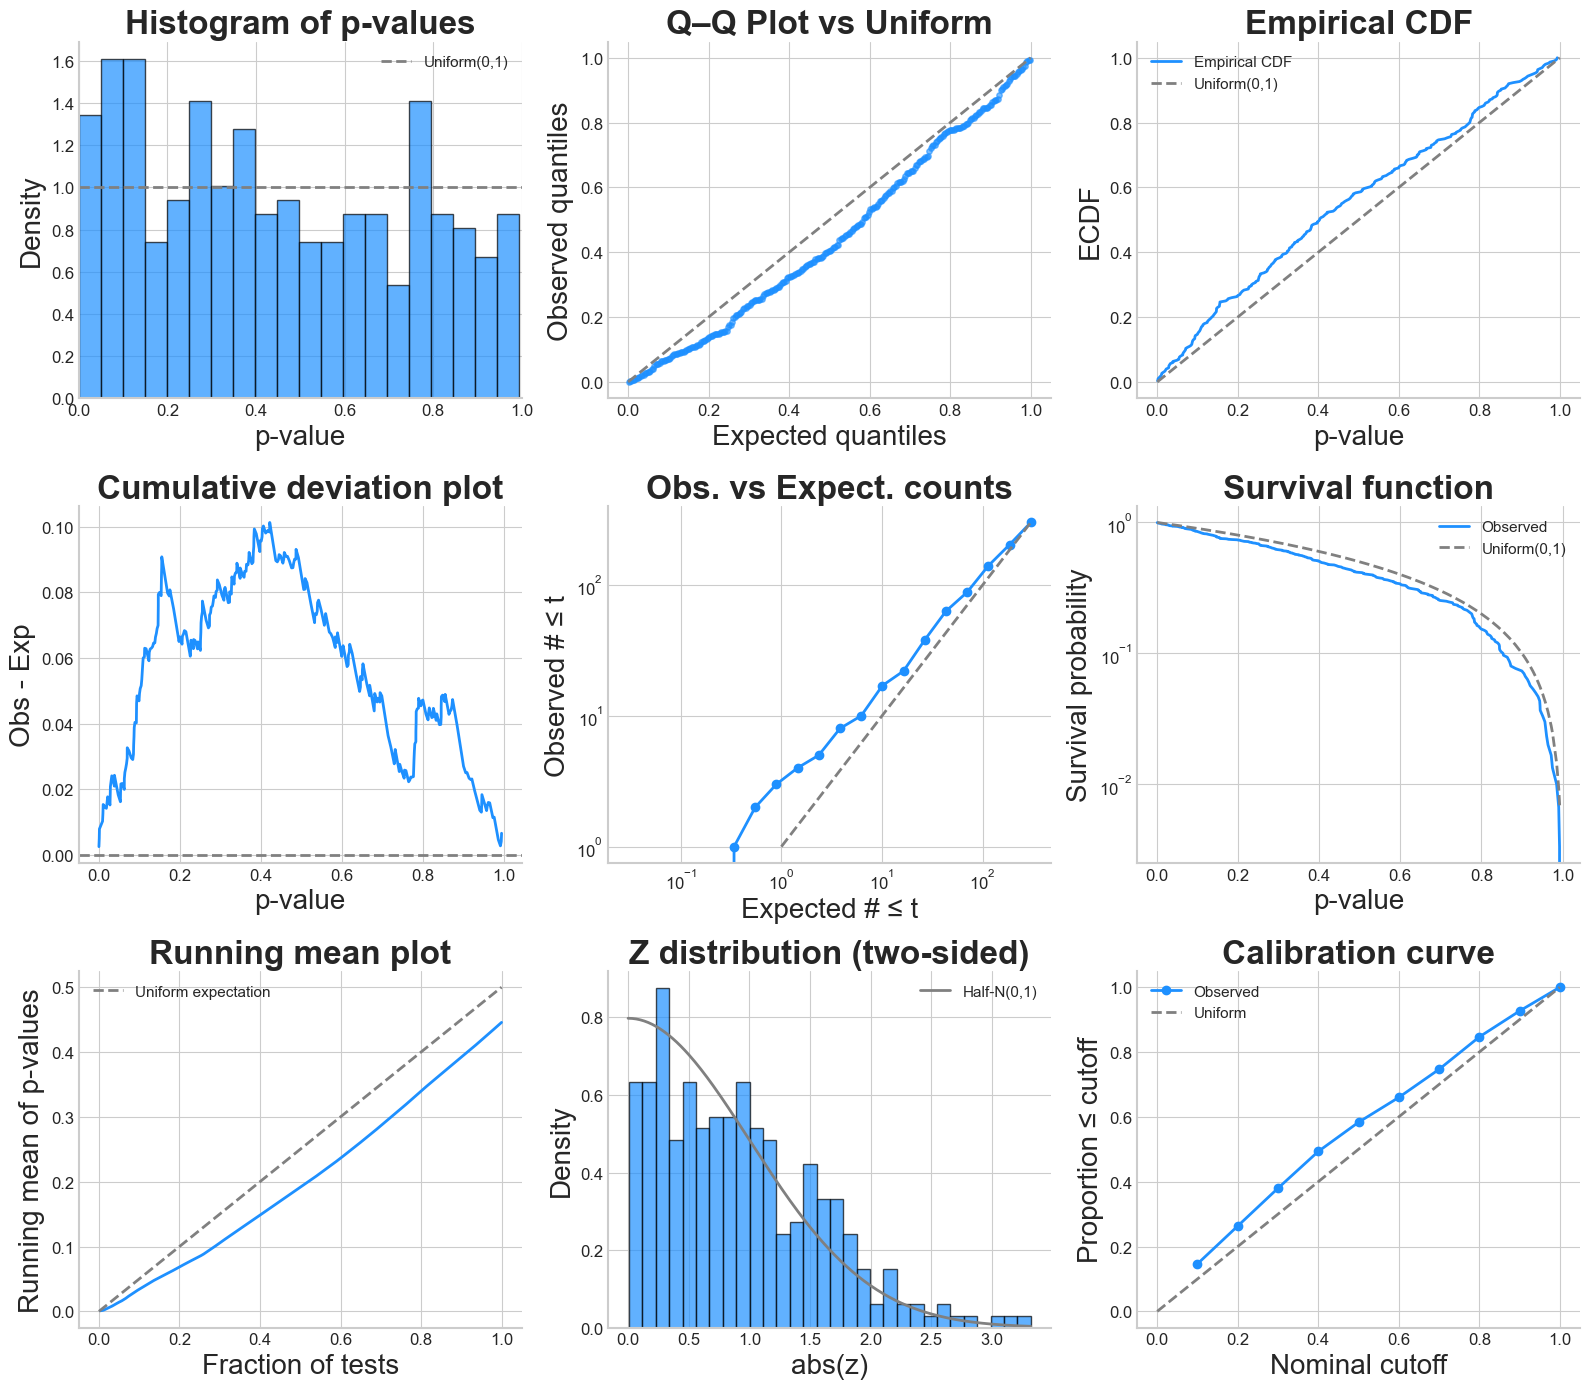

<Figure size 640x480 with 0 Axes>

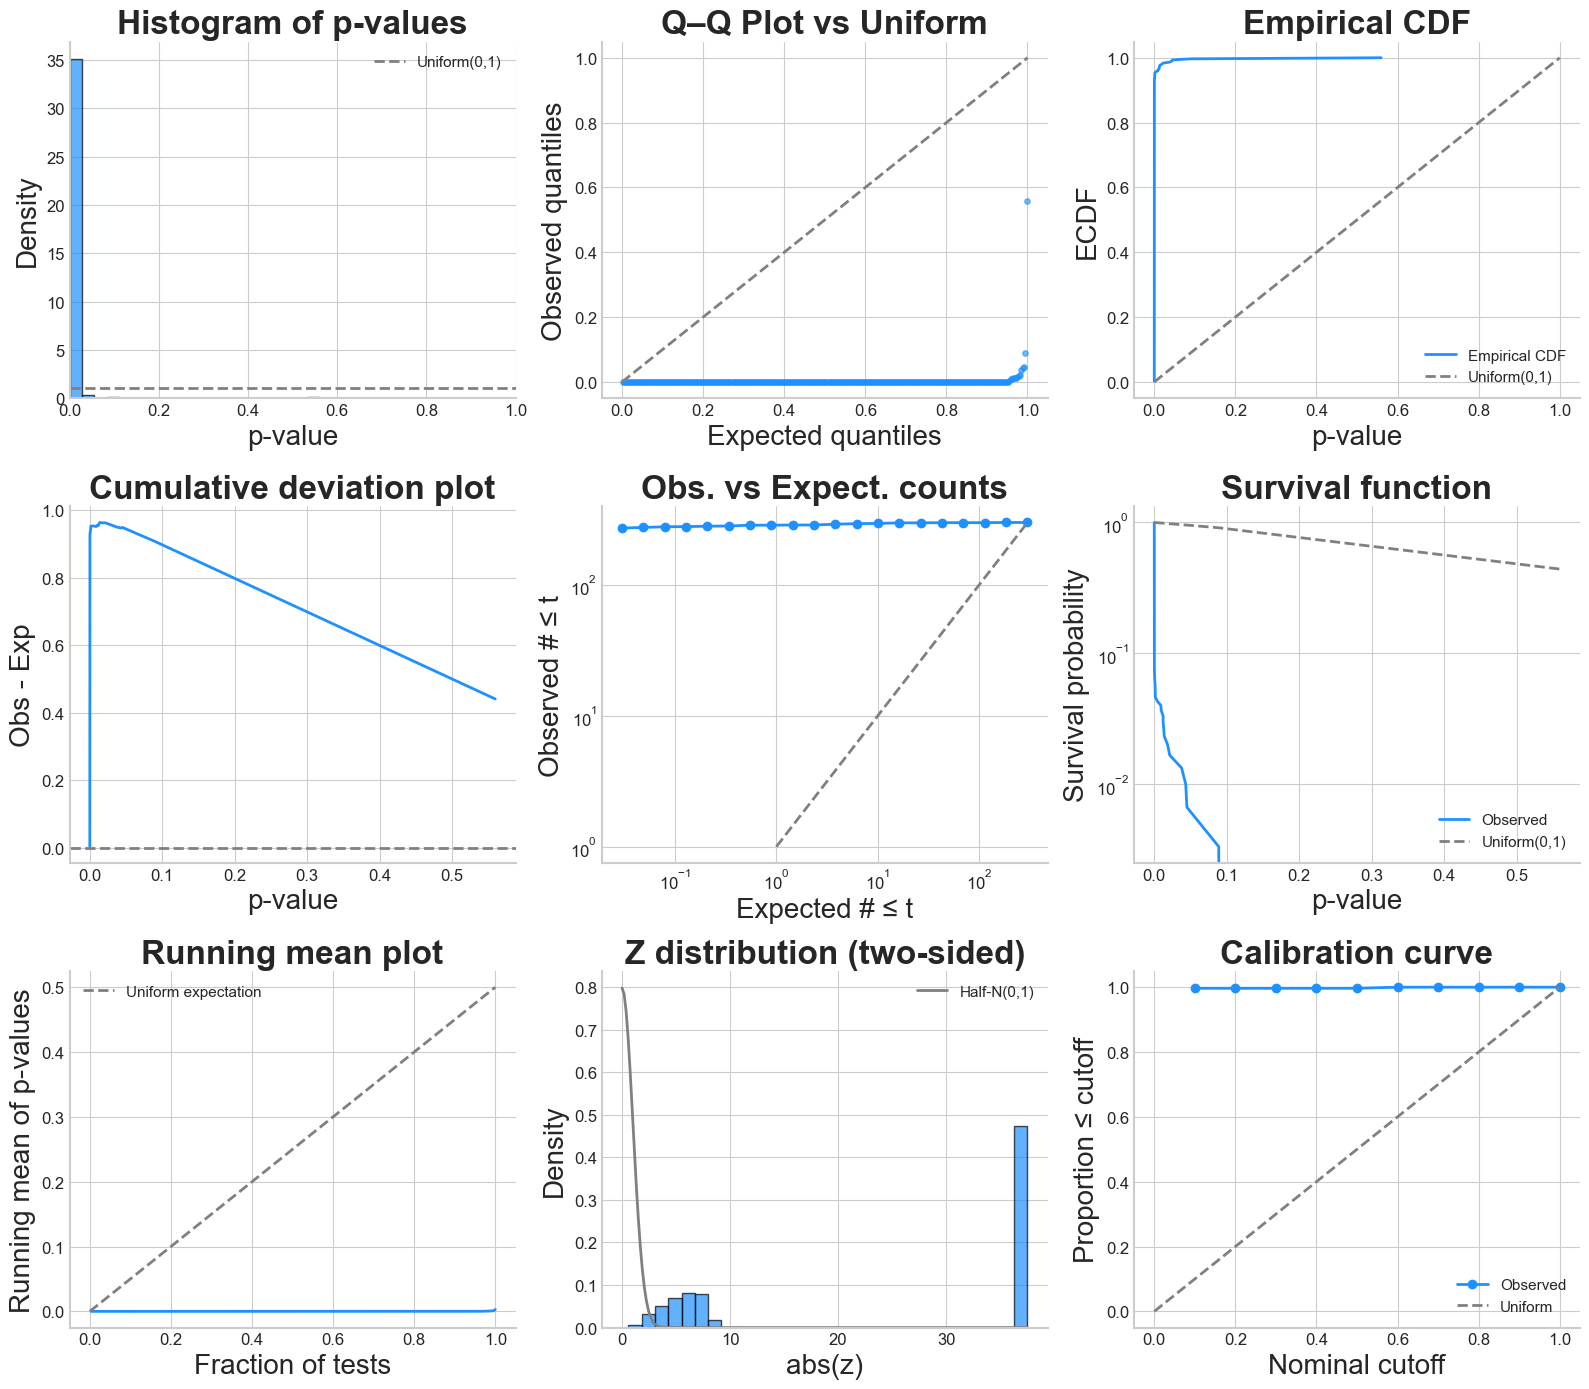

<Figure size 640x480 with 0 Axes>

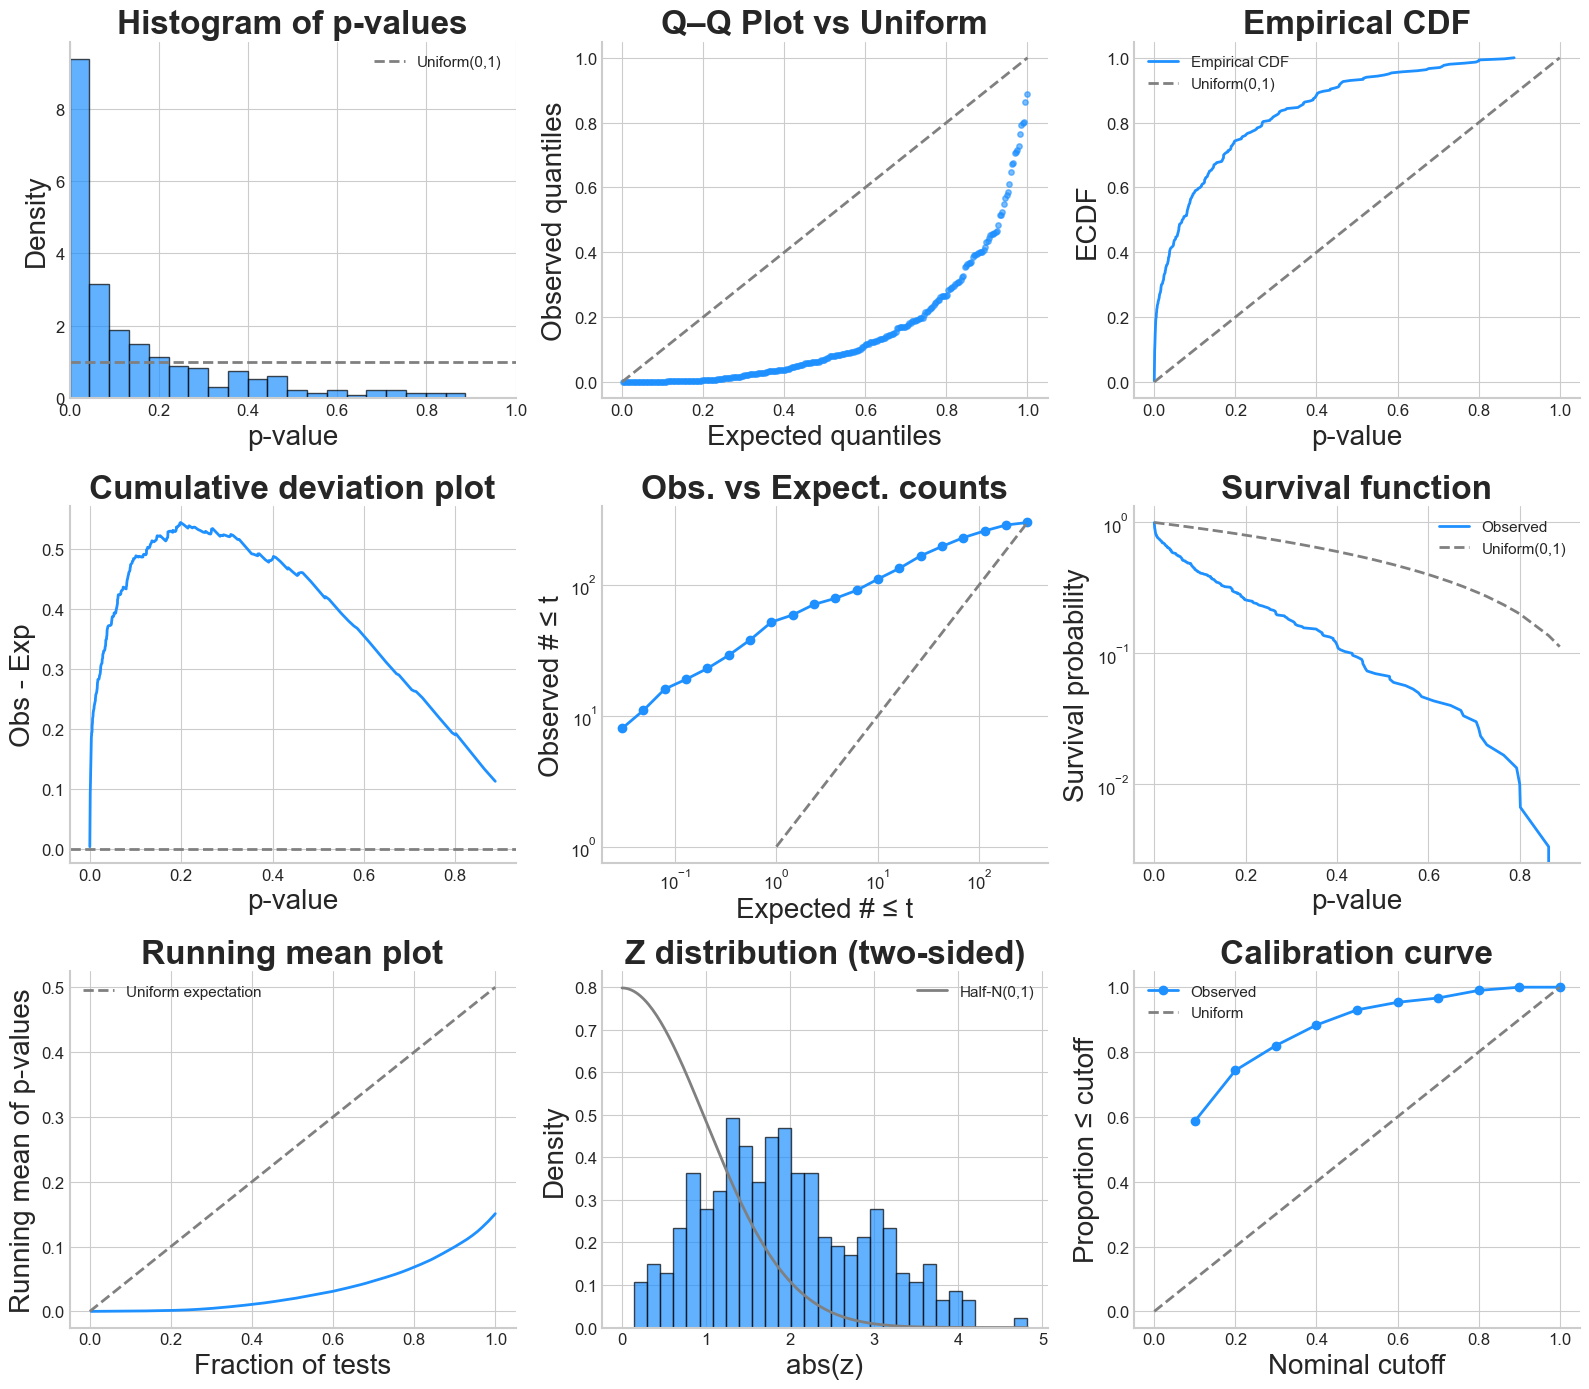

<Figure size 640x480 with 0 Axes>

In [5]:
for name, pvals in pvals_dict.items():
    fig = plot_pvalue_diagnostics_grid(pvals)
    fig.suptitle(f"P-value Calibration Grid - {name} Null", fontsize=16)
    plt.tight_layout()
    plt.show()


## 4. Power Analysis Under Alternatives

We evaluate the statistical power of the `srivastava_2005_sphericity` test. Power is the probability of correctly rejecting the null hypothesis when the alternative is true (measured here as the proportion of p-values $< 0.05$).

We consider two alternative covariance structures:
1. **Spiked Covariance Matrix**: A few eigenvalues are spiked (inflated) to simulate a non-spherical variance structure.
2. **Toeplitz (AR(1)) Covariance Matrix**: An autoregressive covariance structure where correlation decays exponentially with distance.

### Power vs. Alternative Strength
We vary the strength of the alternative covariance structure and record the rejection rates. The parameter value at the start (1.0 for spike, 0.0 for Toeplitz rho) corresponds to a spherical covariance, where power should be approximately $\alpha = 0.05$.


In [6]:
M_alt = 100
n, p = 100, 30

# Spiked alternative
spike_values = np.array([1.0, 1.5, 2.0, 3.0, 4.5, 6.0])
pvals_spiked = []

for spike in spike_values:
    col_pvals = []
    cov_matrix = generate_spiked_covariance(p, spike_eigenvalue=spike, num_spikes=1, rng=rng) if spike > 1.0 else np.eye(p)
    for _ in range(M_alt):
        X = generate_heavy_tailed_samples(cov_matrix, n, dist_type="normal", rng=rng)
        res = srivastava_2005_sphericity(X)
        col_pvals.append(res["p_value"])
    pvals_spiked.append(col_pvals)

pvals_spiked = np.array(pvals_spiked).T


In [7]:
# Toeplitz alternative
rho_values = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
pvals_toeplitz = []

for rho in rho_values:
    col_pvals = []
    cov_matrix = generate_toeplitz_cov(p, rho) if rho > 0.0 else np.eye(p)
    for _ in range(M_alt):
        X = generate_heavy_tailed_samples(cov_matrix, n, dist_type="normal", rng=rng)
        res = srivastava_2005_sphericity(X)
        col_pvals.append(res["p_value"])
    pvals_toeplitz.append(col_pvals)

pvals_toeplitz = np.array(pvals_toeplitz).T


Plotting power curve for Spiked Covariance:


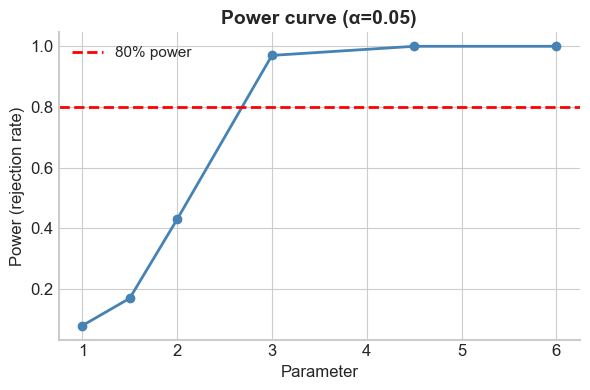

In [8]:
# Plotting spiked power curve
print("Plotting power curve for Spiked Covariance:")
plot_power_curve(pvals_spiked, spike_values, alpha=0.05)


Plotting power curve for Toeplitz Covariance:


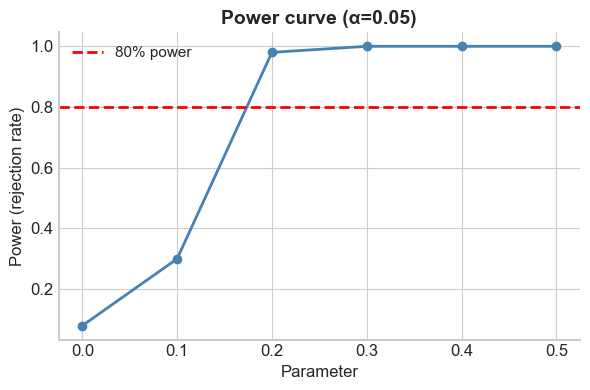

In [9]:
# Plotting Toeplitz power curve
print("Plotting power curve for Toeplitz Covariance:")
plot_power_curve(pvals_toeplitz, rho_values, alpha=0.05)


### Power Heatmap Over Sample Sizes ($n$) and Dimensions ($p$)
We now analyze how power varies over a grid of sample sizes and dimensions under a fixed spiked alternative covariance.


Running grid simulations...
Plotting power heatmap over sample sizes (n) and dimensions (p):


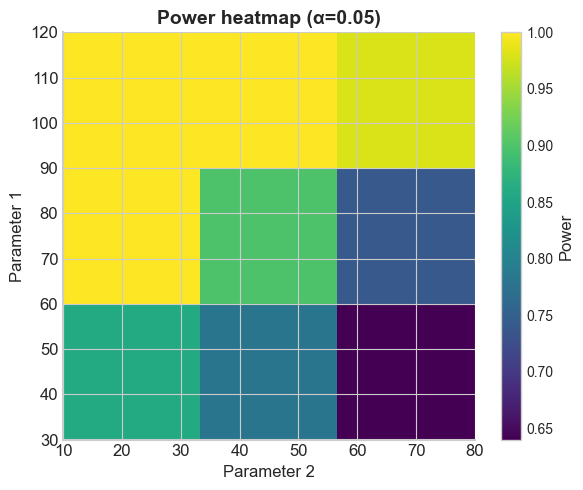

In [10]:
sample_sizes = np.array([30, 60, 120])
dimensions = np.array([10, 30, 80])
pvals_grid = []
spike_val = 3.5

print("Running grid simulations...")
for n_val in sample_sizes:
    row_pvals = []
    for p_val in dimensions:
        cell_pvals = []
        cov_matrix = generate_spiked_covariance(p_val, spike_eigenvalue=spike_val, num_spikes=1, rng=rng)
        for _ in range(50):
            X = generate_heavy_tailed_samples(cov_matrix, n_val, dist_type="normal", rng=rng)
            res = srivastava_2005_sphericity(X)
            cell_pvals.append(res["p_value"])
        row_pvals.append(cell_pvals)
    pvals_grid.append(row_pvals)

pvals_grid = np.transpose(np.array(pvals_grid), (2, 0, 1))

print("Plotting power heatmap over sample sizes (n) and dimensions (p):")
plot_power_heatmap(pvals_grid, sample_sizes, dimensions, alpha=0.05)
